In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

In [2]:
communication_matrix = pd.read_csv(
    "data/outputs/communication_matrix.csv",
    index_col=0
)

communication_matrix.shape

(138, 3489)

In [3]:
corr = communication_matrix.corr(method="spearman")

corr = corr.fillna(0)
np.fill_diagonal(corr.values, 1)

corr.shape

(3489, 3489)

In [4]:
from scipy.spatial.distance import squareform

distance = 1 - np.abs(corr)
distance = distance.clip(0, 1)

condensed = squareform(distance.values)

Z = linkage(condensed, method="average")

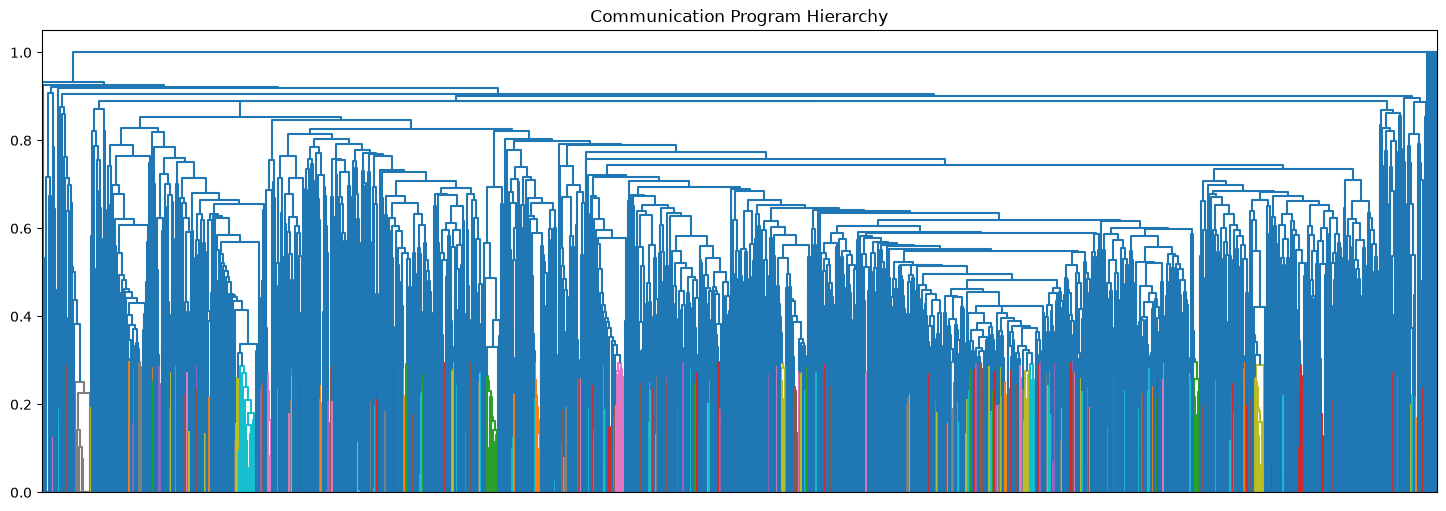

In [5]:
plt.figure(figsize=(18,6))

dendrogram(
    Z,
    no_labels=True,
    color_threshold=0.3
)

plt.title("Communication Program Hierarchy")
plt.show()

In [6]:
clusters = fcluster(
    Z,
    t=0.7,
    criterion="distance"
)

program_df = pd.DataFrame({
    "feature": communication_matrix.columns,
    "program": clusters
})

program_df.head()

,feature,program
0,LGALS9→PTPRC,87
1,LGALS9→MET,87
2,LGALS9→CD44,87
3,LGALS9→LRP1,87
4,LGALS9→CD47,87


In [7]:
program_sizes = (
    program_df["program"]
    .value_counts()
    .sort_values(ascending=False)
)

program_sizes.head(20)

program
87     1424
89      341
37      185
71      125
70      122
24       94
85       93
91       83
79       78
13       65
81       63
72       55
43       45
36       32
56       26
74       24
112      23
31       21
52       18
33       18
Name: count, dtype: int64

In [8]:
for p in program_sizes.index[:10]:
    print(f"\nProgram {p}")
    display(program_df[program_df.program == p].head(20))


Program 87


,feature,program
0,LGALS9→PTPRC,87
1,LGALS9→MET,87
2,LGALS9→CD44,87
3,LGALS9→LRP1,87
4,LGALS9→CD47,87
5,LGALS9→PTPRK,87
6,LGALS9→COLEC12,87
7,LGALS9→HAVCR2,87
8,LGALS9→MRC2,87
9,DLL1→NOTCH1,87



Program 89


,feature,program
44,ADAM11→ITGA4,89
100,ANXA1→GRM7,89
139,FCER2→CR2,89
182,TGFB3→ITGB6,89
197,NCAM1→FGFR1,89
201,NCAM1→ROBO3,89
202,NCAM1→ROBO1,89
248,EFNA1→EPHA5,89
251,EFNA1→EPHA7,89
306,TNFSF10→TNFRSF11B,89



Program 37


...

,feature,program
33,ADAM12→ITGA9,91
35,TNFSF12→CD163,91
104,HLA-A→ERBB2,91
143,THBS1→TNFRSF11B,91
151,THBS1→PTPRJ,91
204,CEACAM1→HAVCR2,91
212,SELL→MADCAM1,91
304,FLT3LG→FLT3,91
374,EFNB1→EPHB6,91
375,EFNB1→ERBB2,91



Program 79


,feature,program
31,EREG→ERBB3,79
61,TGFA→ERBB3,79
62,TGFA→ERBB4,79
189,CDH1→LRP5,79
191,CDH1→IGF1R,79
192,CDH1→PTPRF,79
200,NCAM1→GFRA1,79
252,EFNA1→EPHA10,79
283,BTC→ERBB3,79
316,EFNA4→EPHA10,79



Program 13


,feature,program
99,ANXA1→MTNR1A,13
126,APP→MTNR1A,13
767,CORT→MTNR1A,13
781,CCL21→MTNR1A,13
800,CXCL11→MTNR1A,13
817,CCL25→MTNR1A,13
824,CCL16→MTNR1A,13
858,CXCL13→MTNR1A,13
977,AGT→MTNR1A,13
1056,POMC→MTNR1A,13


In [9]:
program_df.to_csv(
    "data/outputs/communication_programs.csv",
    index=False
)

print("Saved communication programs.")

Saved communication programs.
